In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("ecommerce_dataset_updated.csv")

df

,User_ID,Product_ID,Category,Price (Rs.),Discount (%),Final_Price(Rs.),Payment_Method,Purchase_Date
0,337c166f,f414122f-e,Sports,36.53,15,31.05,Net Banking,12-11-2024
1,d38a19bf,fde50f9c-5,Clothing,232.79,20,186.23,Net Banking,09-02-2024
2,d7f5f0b0,0d96fc90-3,Sports,317.02,25,237.76,Credit Card,01-09-2024
3,395d4994,964fc44b-d,Toys,173.19,25,129.89,UPI,01-04-2024
4,a83c145c,d70e2fc6-e,Beauty,244.80,20,195.84,Net Banking,27-09-2024
...,...,...,...,...,...,...,...,...
3655,67abda0a,28714133-6,Beauty,486.79,0,486.79,UPI,14-05-2024
3656,34ebc1a0,08838c2c-9,Toys,212.87,15,180.94,Cash on Delivery,19-11-2024
3657,1defd3b1,c39a4f16-6,Home & Kitchen,389.76,0,389.76,Net Banking,07-08-2024
3658,0611293d,b4f67f96-9,Electronics,447.66,30,313.36,UPI,21-05-2024


In [4]:
df.head()

,User_ID,Product_ID,Category,Price (Rs.),Discount (%),Final_Price(Rs.),Payment_Method,Purchase_Date
0,337c166f,f414122f-e,Sports,36.53,15,31.05,Net Banking,12-11-2024
1,d38a19bf,fde50f9c-5,Clothing,232.79,20,186.23,Net Banking,09-02-2024
2,d7f5f0b0,0d96fc90-3,Sports,317.02,25,237.76,Credit Card,01-09-2024
3,395d4994,964fc44b-d,Toys,173.19,25,129.89,UPI,01-04-2024
4,a83c145c,d70e2fc6-e,Beauty,244.80,20,195.84,Net Banking,27-09-2024


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3660 entries, 0 to 3659
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           3660 non-null   str    
 1   Product_ID        3660 non-null   str    
 2   Category          3660 non-null   str    
 3   Price (Rs.)       3660 non-null   float64
 4   Discount (%)      3660 non-null   int64  
 5   Final_Price(Rs.)  3660 non-null   float64
 6   Payment_Method    3660 non-null   str    
 7   Purchase_Date     3660 non-null   str    
dtypes: float64(2), int64(1), str(5)
memory usage: 392.7 KB


In [6]:
df.describe()

,Price (Rs.),Discount (%),Final_Price(Rs.)
count,3660.000000,3660.000000,3660.000000
mean,254.800675,18.825137,206.906579
std,141.682621,14.731338,122.687844
min,10.090000,0.000000,5.890000
25%,134.012500,5.000000,104.512500
50%,253.845000,15.000000,199.185000
75%,377.595000,25.000000,304.117500
max,499.960000,50.000000,496.820000


In [7]:
# Data Cleaning

df.isnull().sum()

User_ID             0
Product_ID          0
Category            0
Price (Rs.)         0
Discount (%)        0
Final_Price(Rs.)    0
Payment_Method      0
Purchase_Date       0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df["Purchase_Date"] = pd.to_datetime(
    df["Purchase_Date"],
    dayfirst=True
)

In [11]:
df.head()

,User_ID,Product_ID,Category,Price (Rs.),Discount (%),Final_Price(Rs.),Payment_Method,Purchase_Date
0,337c166f,f414122f-e,Sports,36.53,15,31.05,Net Banking,2024-11-12
1,d38a19bf,fde50f9c-5,Clothing,232.79,20,186.23,Net Banking,2024-02-09
2,d7f5f0b0,0d96fc90-3,Sports,317.02,25,237.76,Credit Card,2024-09-01
3,395d4994,964fc44b-d,Toys,173.19,25,129.89,UPI,2024-04-01
4,a83c145c,d70e2fc6-e,Beauty,244.80,20,195.84,Net Banking,2024-09-27


In [12]:
df["Month"] = df["Purchase_Date"].dt.month_name()

df["Year"] = df["Purchase_Date"].dt.year

In [13]:
df

,User_ID,Product_ID,Category,Price (Rs.),Discount (%),Final_Price(Rs.),Payment_Method,Purchase_Date,Month,Year
0,337c166f,f414122f-e,Sports,36.53,15,31.05,Net Banking,2024-11-12,November,2024
1,d38a19bf,fde50f9c-5,Clothing,232.79,20,186.23,Net Banking,2024-02-09,February,2024
2,d7f5f0b0,0d96fc90-3,Sports,317.02,25,237.76,Credit Card,2024-09-01,September,2024
3,395d4994,964fc44b-d,Toys,173.19,25,129.89,UPI,2024-04-01,April,2024
4,a83c145c,d70e2fc6-e,Beauty,244.80,20,195.84,Net Banking,2024-09-27,September,2024
...,...,...,...,...,...,...,...,...,...,...
3655,67abda0a,28714133-6,Beauty,486.79,0,486.79,UPI,2024-05-14,May,2024
3656,34ebc1a0,08838c2c-9,Toys,212.87,15,180.94,Cash on Delivery,2024-11-19,November,2024
3657,1defd3b1,c39a4f16-6,Home & Kitchen,389.76,0,389.76,Net Banking,2024-08-07,August,2024
3658,0611293d,b4f67f96-9,Electronics,447.66,30,313.36,UPI,2024-05-21,May,2024


In [14]:
df["Final_Price(Rs.)"].sum()

np.float64(757278.08)

In [16]:
df["Final_Price(Rs.)"].mean()

np.float64(206.90657923497267)

In [17]:
df["Final_Price(Rs.)"].max()

496.82

In [18]:
df["Final_Price(Rs.)"].min()

5.89

In [19]:
category_sales = df.groupby("Category")["Final_Price(Rs.)"].sum()

print(category_sales)

Category
Beauty            104215.10
Books             111149.35
Clothing          115314.84
Electronics       100462.23
Home & Kitchen    110328.08
Sports            108518.79
Toys              107289.69
Name: Final_Price(Rs.), dtype: float64


In [20]:
payment = df["Payment_Method"].value_counts()

print(payment)

Payment_Method
Credit Card         760
UPI                 757
Debit Card          731
Net Banking         716
Cash on Delivery    696
Name: count, dtype: int64


In [21]:
monthly = df.groupby("Month")["Final_Price(Rs.)"].sum()

print(monthly)

Month
April        74365.13
August       71506.96
February     69186.34
January      69009.43
July         72798.23
June         64256.66
March        71325.40
May          68837.25
November     51915.08
October      76034.51
September    68043.09
Name: Final_Price(Rs.), dtype: float64


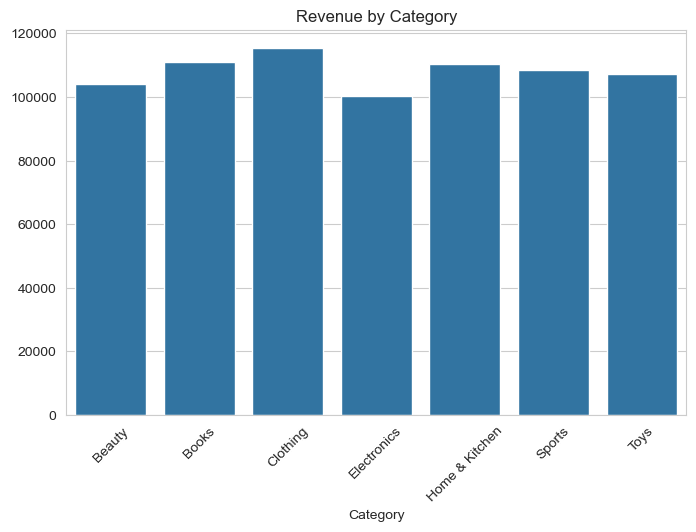

In [22]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Revenue by Category")
plt.xticks(rotation=45)
plt.show()

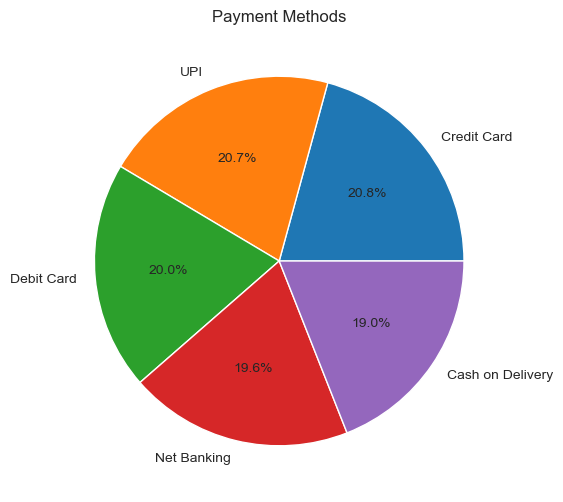

In [23]:
plt.figure(figsize=(6,6))

plt.pie(
    payment,
    labels=payment.index,
    autopct="%1.1f%%"
)

plt.title("Payment Methods")
plt.show()

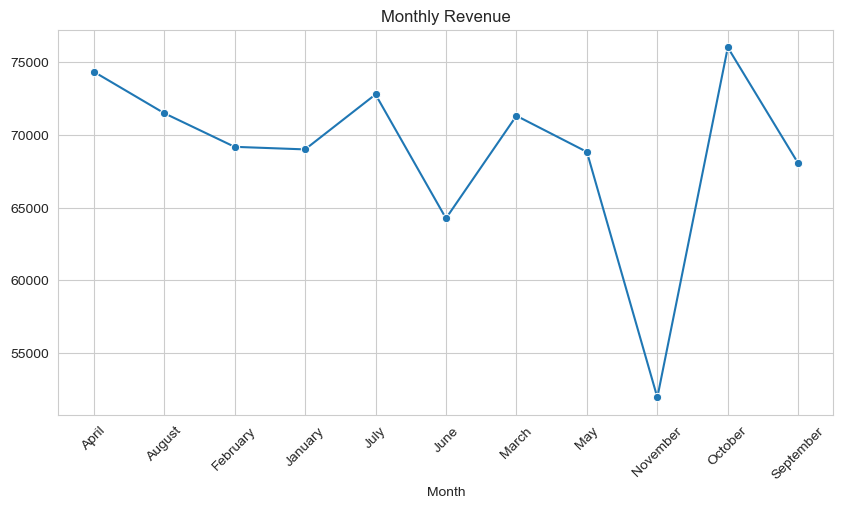

In [24]:
plt.figure(figsize=(10,5))

sns.lineplot(
    x=monthly.index,
    y=monthly.values,
    marker="o"
)

plt.title("Monthly Revenue")
plt.xticks(rotation=45)
plt.show()

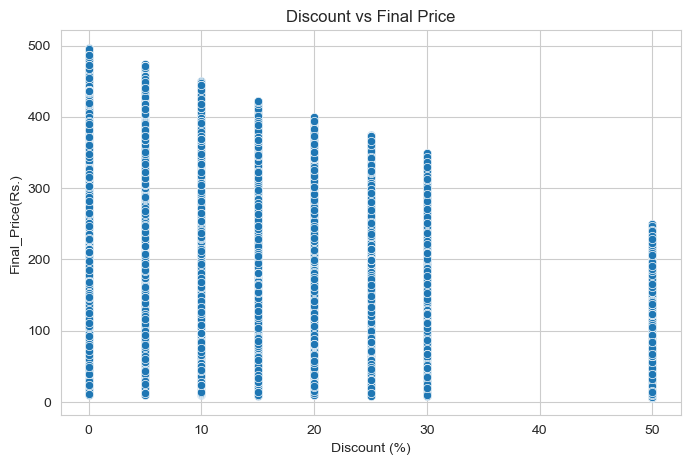

In [25]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Discount (%)",
    y="Final_Price(Rs.)"
)

plt.title("Discount vs Final Price")
plt.show()

C:\Users\Dictator\AppData\Local\Temp\ipykernel_23620\1147278419.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


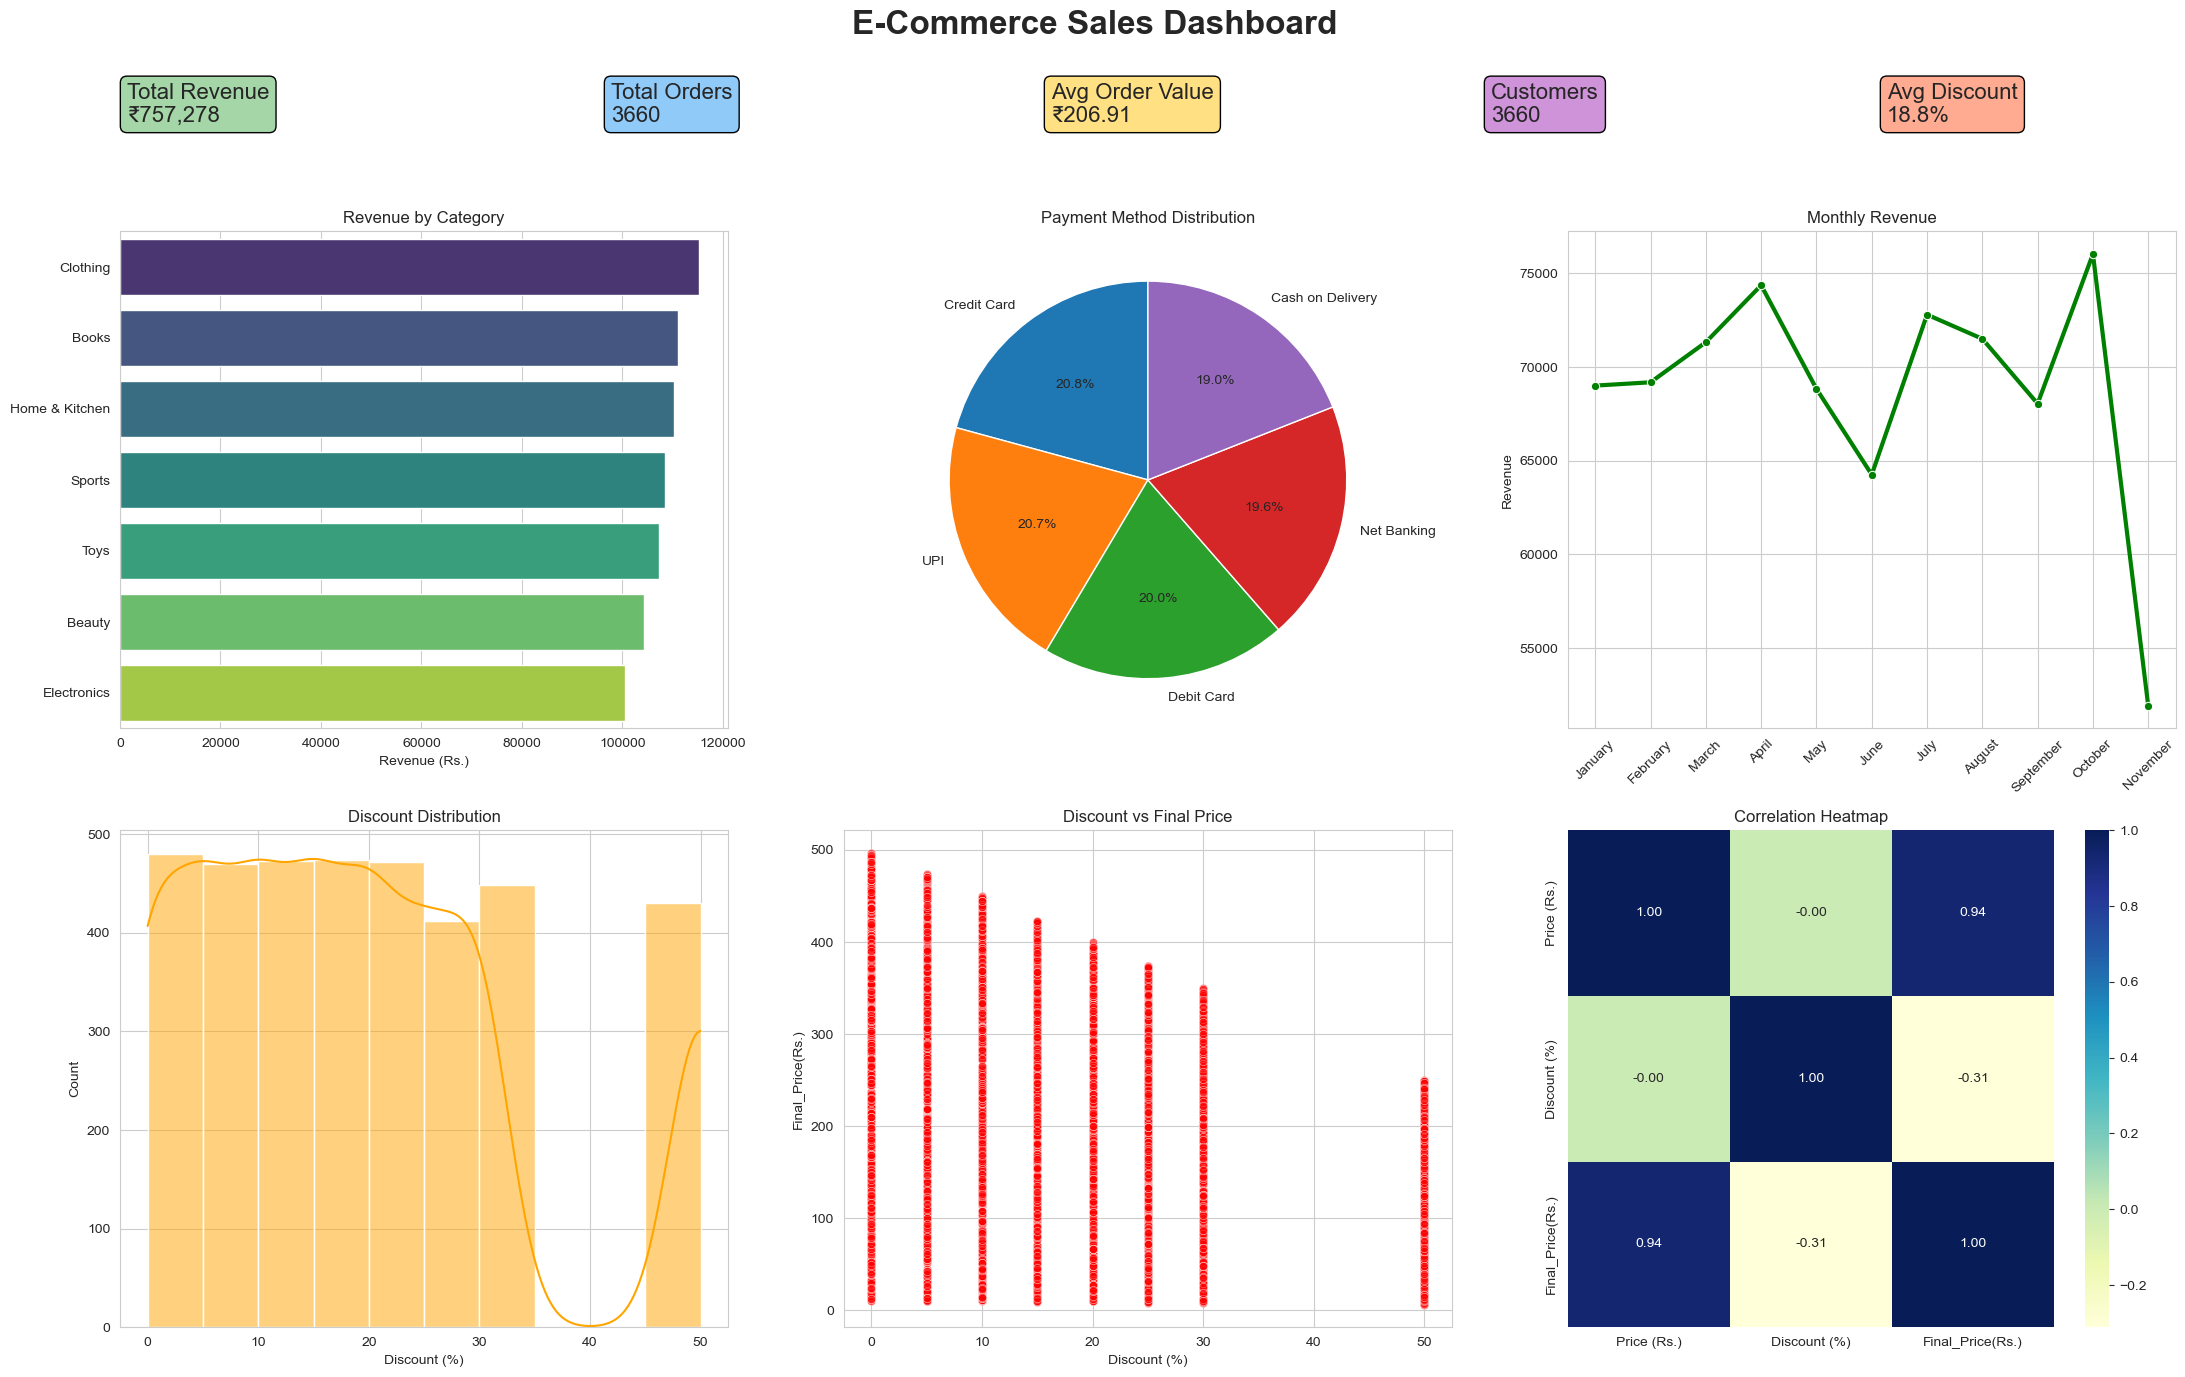

In [27]:

# ==========================
# KPIs
# ==========================

total_revenue = df["Final_Price(Rs.)"].sum()
total_orders = len(df)
avg_order = df["Final_Price(Rs.)"].mean()
total_customers = df["User_ID"].nunique()
avg_discount = df["Discount (%)"].mean()

# Monthly Revenue (Correct Order)
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]

monthly = df.groupby("Month")["Final_Price(Rs.)"].sum().reindex(month_order)

# Category Revenue
category = df.groupby("Category")["Final_Price(Rs.)"].sum().sort_values(ascending=False)

# Payment Method
payment = df["Payment_Method"].value_counts()

# ==========================
# Dashboard
# ==========================

fig = plt.figure(figsize=(22,14))
fig.suptitle("E-Commerce Sales Dashboard", fontsize=24, fontweight='bold')

# --------------------------
# KPI Cards
# --------------------------

plt.figtext(
    0.06,0.90,
    f"Total Revenue\n₹{total_revenue:,.0f}",
    fontsize=16,
    bbox=dict(boxstyle="round",facecolor="#A5D6A7",edgecolor="black")
)

plt.figtext(
    0.28,0.90,
    f"Total Orders\n{total_orders}",
    fontsize=16,
    bbox=dict(boxstyle="round",facecolor="#90CAF9",edgecolor="black")
)

plt.figtext(
    0.48,0.90,
    f"Avg Order Value\n₹{avg_order:.2f}",
    fontsize=16,
    bbox=dict(boxstyle="round",facecolor="#FFE082",edgecolor="black")
)

plt.figtext(
    0.68,0.90,
    f"Customers\n{total_customers}",
    fontsize=16,
    bbox=dict(boxstyle="round",facecolor="#CE93D8",edgecolor="black")
)

plt.figtext(
    0.86,0.90,
    f"Avg Discount\n{avg_discount:.1f}%",
    fontsize=16,
    bbox=dict(boxstyle="round",facecolor="#FFAB91",edgecolor="black")
)

# --------------------------
# Revenue by Category
# --------------------------

plt.subplot(2,3,1)

sns.barplot(
    x=category.values,
    y=category.index,
    palette="viridis"
)

plt.title("Revenue by Category")
plt.xlabel("Revenue (Rs.)")
plt.ylabel("")

# --------------------------
# Payment Method
# --------------------------

plt.subplot(2,3,2)

plt.pie(
    payment.values,
    labels=payment.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Payment Method Distribution")

# --------------------------
# Monthly Revenue
# --------------------------

plt.subplot(2,3,3)

sns.lineplot(
    x=monthly.index,
    y=monthly.values,
    marker="o",
    linewidth=3,
    color="green"
)

plt.xticks(rotation=45)

plt.title("Monthly Revenue")
plt.xlabel("")
plt.ylabel("Revenue")

# --------------------------
# Discount Distribution
# --------------------------

plt.subplot(2,3,4)

sns.histplot(
    df["Discount (%)"],
    bins=10,
    kde=True,
    color="orange"
)

plt.title("Discount Distribution")

# --------------------------
# Discount vs Final Price
# --------------------------

plt.subplot(2,3,5)

sns.scatterplot(
    data=df,
    x="Discount (%)",
    y="Final_Price(Rs.)",
    alpha=0.6,
    color="red"
)

plt.title("Discount vs Final Price")

# --------------------------
# Correlation Heatmap
# --------------------------

plt.subplot(2,3,6)

corr = df[["Price (Rs.)","Discount (%)","Final_Price(Rs.)"]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout(rect=[0,0,1,0.88])

plt.show()